In [5]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\Nishanth\Downloads\ecommerce_sales.csv")
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       505 non-null    int64  
 1   Order_Date     505 non-null    object 
 2   Customer_ID    505 non-null    object 
 3   Customer_Name  505 non-null    object 
 4   City           505 non-null    object 
 5   State          505 non-null    object 
 6   Category       505 non-null    object 
 7   Sub_Category   505 non-null    object 
 8   Product        505 non-null    object 
 9   Quantity       505 non-null    int64  
 10  Unit_Price     505 non-null    int64  
 11  Discount       505 non-null    int64  
 12  Sales          505 non-null    float64
 13  Cost           505 non-null    float64
 14  Profit         500 non-null    float64
 15  Payment_Mode   500 non-null    object 
 16  Rating         500 non-null    float64
 17  Delivery_Days  505 non-null    int64  
dtypes: float64

(505, 18)

In [ ]:
!pip install matplotlib

In [11]:
df.isnull().sum()


Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
City             0
State            0
Category         0
Sub_Category     0
Product          0
Quantity         0
Unit_Price       0
Discount         0
Sales            0
Cost             0
Profit           5
Payment_Mode     5
Rating           5
Delivery_Days    0
dtype: int64

In [13]:
df.duplicated().sum()

5

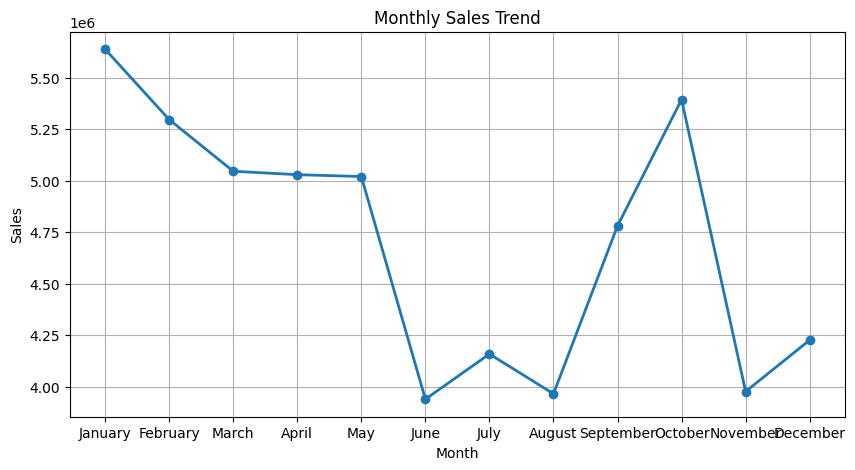

In [21]:
"""Business Scenario

The Clientasks

"How did our monthly sales perform throughout the year?"
A Line Chart is best because we want to show a trend over time.
"""
import pandas as pd
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv(r"C:\Users\Nishanth\Downloads\ecommerce_sales.csv")
# Convert date
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
# Extract month
df["Month"] = df["Order_Date"].dt.month_name()
# Monthly sales
monthly_sales = df.groupby("Month")["Sales"].sum()
# Arrange months
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]
monthly_sales = monthly_sales.reindex(month_order)

# Plot
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

""" Exercise
Change the line color to green.
Change the marker to *.
Increase the line width to 4.
Display monthly Profit instead of Sales.
Remove the grid.
Change the figure size to 12 × 6.
"""

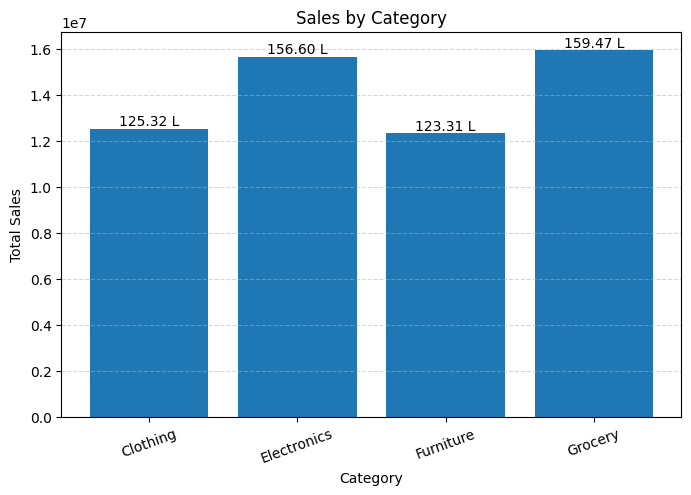

'Change the bar color to orange.\nDisplay Profit instead of Sales.\nIncrease the figure size to 10 × 6.\nRemove the grid.\nSort the categories in descending order of sales before plotting.\nDisplay the sales values in Lakhs (e.g., 45.2 L) instead of raw numbers.\n'

In [43]:
#Visualization 2 – Bar Chart
"""The Sales Manager asks:
"Which product category generated the highest sales?"
Categories in our dataset:
Electronics
Furniture
Clothing
Grocery

Since we are comparing categories, a Bar Chart is the best choice."""


import pandas as pd
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv(r"C:\Users\Nishanth\Downloads\ecommerce_sales.csv")

# Group sales by category
category_sales = df.groupby("Category")["Sales"].sum()

# Create figure
plt.figure(figsize=(8,5))

# Draw bars
plt.bar(
    category_sales.index,
    category_sales.values
)

# Title and labels
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

# Rotate x-axis labels
plt.xticks(rotation=20)

# Show values on bars
for i, value in enumerate(category_sales.values):
    plt.text(i, value, f"{value/100000:,.2f} L", ha="center", va="bottom")

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Display chart
plt.show()

"""Change the bar color to orange.
Display Profit instead of Sales.
Increase the figure size to 10 × 6.
Remove the grid.
Sort the categories in descending order of sales before plotting.
Display the sales values in Lakhs (e.g., 45.2 L) instead of raw numbers.
"""

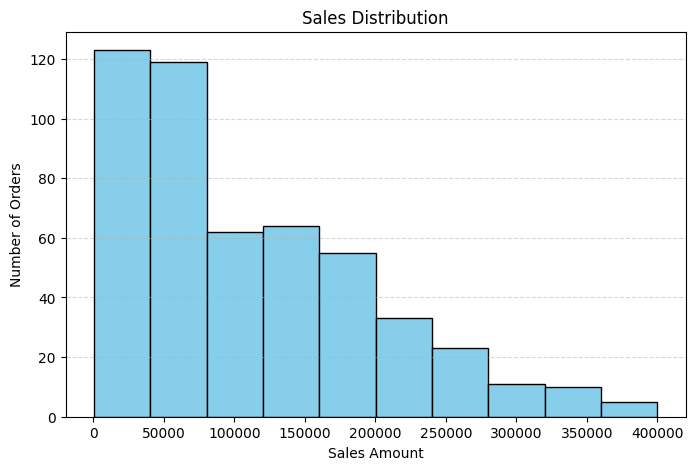

In [27]:
#Visualization 3 – Histogram
"""
Sales Manager asks:

"How are our sales values distributed?"

Questions we want to answer:

Are most orders low-value?
Are there many high-value orders?
Is the data evenly distributed?
Are there any unusually large sales?

A Histogram is the best chart because it shows the frequency distribution of a numerical column.
"""

import pandas as pd
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv(r"C:\Users\Nishanth\Downloads\ecommerce_sales.csv")

# Create figure
plt.figure(figsize=(8,5))

# Histogram
plt.hist(
    df["Sales"],
    bins=10,
    color="skyblue",
    edgecolor="black"
)

# Title
plt.title("Sales Distribution")

# Labels
plt.xlabel("Sales Amount")
plt.ylabel("Number of Orders")

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Show chart
plt.show()

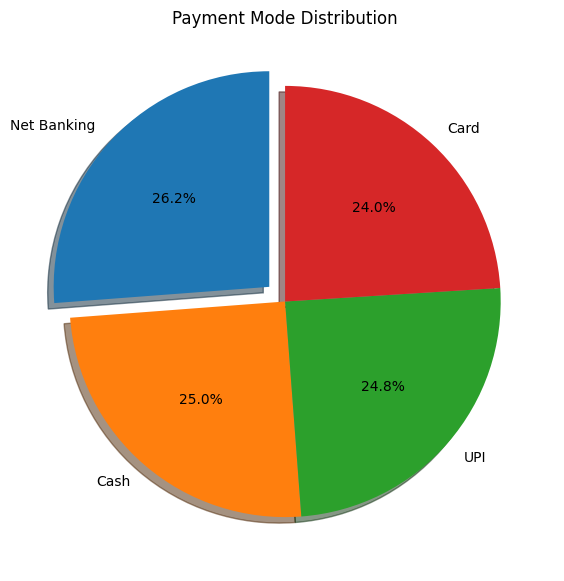

In [31]:
#pie chart
"""
he Finance Manager asks:

"Which payment mode do customers use the most?"
Our dataset contains:

UPI
Card
Cash
Net Banking

We want to know the percentage share of each payment mode.
"""

import pandas as pd
import matplotlib.pyplot as plt

# Read dataset

df = pd.read_csv(r"C:\Users\Nishanth\Downloads\ecommerce_sales.csv")

# Count payment modes
payment_mode = df["Payment_Mode"].value_counts()

# Highlight UPI
explode = [0.1, 0, 0, 0]

# Create figure
plt.figure(figsize=(7,7))

# Draw pie chart
plt.pie(
    payment_mode.values,
    labels=payment_mode.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=explode,
    shadow=True
)

# Title
plt.title("Payment Mode Distribution")

# Display chart
plt.show()

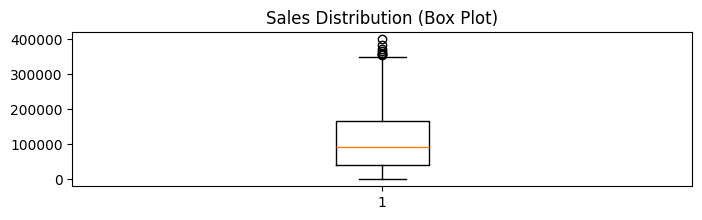

In [33]:
#box plot
"""Sales Manager asks:
"Are there any unusually high or low sales orders (outliers)?"
For example:
Most orders are between ₹20,000 and ₹80,000.
But suddenly one order is
₹4,50,000
Is it
A premium customer?
A data entry mistake?
A bulk order?

A Box Plot helps us identify such unusual values."""

import pandas as pd
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv(r"C:\Users\Nishanth\Downloads\ecommerce_sales.csv")

# Create figure
plt.figure(figsize=(8,2))

# Draw boxplot
plt.boxplot(df["Sales"])

# Title
plt.title("Sales Distribution (Box Plot)")

# Show
plt.show()

#Question
#Are there any unusually long delivery times?

In [35]:
#detecting the outliers

import pandas as pd

# Read dataset
df = pd.read_csv(r"C:\Users\Nishanth\Downloads\ecommerce_sales.csv")

# Calculate Quartiles
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate Limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Find Outliers
outliers = df[
    (df["Sales"] < lower_limit) |
    (df["Sales"] > upper_limit)
]

print("Outliers Found:", len(outliers))

# Remove Outliers
df_clean = df[
    (df["Sales"] >= lower_limit) &
    (df["Sales"] <= upper_limit)
]

print("Original Shape :", df.shape)
print("Clean Shape    :", df_clean.shape)

Outliers Found: 8
Original Shape : (505, 18)
Clean Shape    : (497, 18)


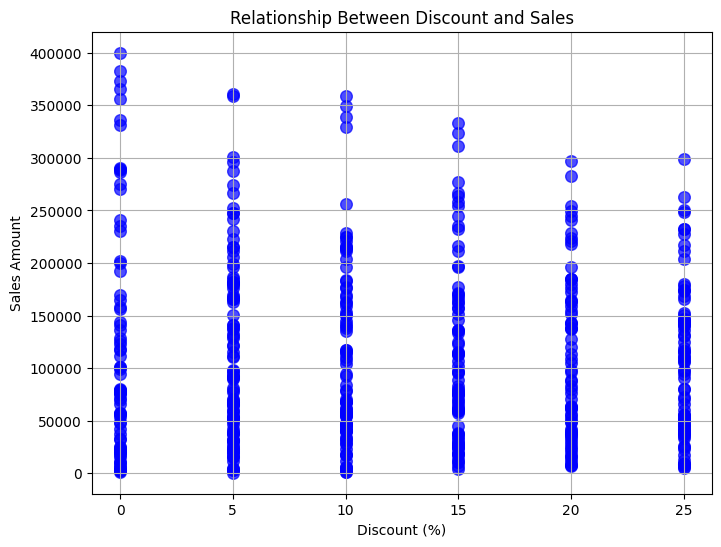

In [39]:
#scatter


import pandas as pd
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv(r"C:\Users\Nishanth\Downloads\ecommerce_sales.csv")

# Create figure
plt.figure(figsize=(8,6))

# Scatter Plot
plt.scatter(
    df["Discount"],
    df["Sales"],
    color="blue",
    marker="o",
    s=70,
    alpha=0.7
)

# Title
plt.title("Relationship Between Discount and Sales")

# Labels
plt.xlabel("Discount (%)")
plt.ylabel("Sales Amount")

# Grid
plt.grid(True)

# Display chart
plt.show()